In [ ]:
# Import library here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

: 

In [2]:
df_train_clean = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")

df_train_clean.head(10)

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.009950,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,False,Day,Day,Day,Day,3.405079,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,3.862833,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,3.422633,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.470004,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,4.784571,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.387980,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,4.952535,2020-11-06,1,11,Clear
5,2,2021-07-02 15:22:00,36.989497,-121.935657,0.033435,Incident on PARK AVE WB near SOQUEL DR Expect ...,Park Ave N,Soquel,Santa Cruz,CA,...,False,Day,Day,Day,Day,5.758376,2021-07-02,15,7,Cloudy
6,2,2019-08-09 08:44:18,30.419380,-91.096611,0.000000,Accident on LA-73 Jefferson Hwy at LA-3064 Ess...,Essen Ln,Baton Rouge,East Baton Rouge,LA,...,False,Day,Day,Day,Day,4.665638,2019-08-09,8,8,Cloudy
7,2,2021-12-10 07:02:30,33.194519,-111.901301,1.015955,Stationary traffic on I-10 E - Pearl Harbor Me...,I-10 E,Maricopa,Pinal,AZ,...,False,Night,Day,Day,Day,4.248495,2021-12-10,7,12,Clear
8,3,2021-04-26 19:57:38,29.384928,-98.512321,0.000000,Three lanes blocked due to accident on I-35 So...,I-35 N,San Antonio,Bexar,TX,...,False,Day,Day,Day,Day,5.332880,2021-04-26,19,4,Clear
9,2,2017-04-18 19:05:08,26.589575,-81.703766,0.000000,Accident on 25th St at Curtis Ave.,25th St SW,Lehigh Acres,Lee,FL,...,False,Day,Day,Day,Day,3.751463,2017-04-18,19,4,Cloudy


In [3]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

## Target Distribution 
เช็คว่า Duration เเละ Distance มีการกระจายตัวเข้าใกล้โค้งปกติ (Normal Distribution) เหมาะสมกับการใช้ Linear Regression หรือไม่

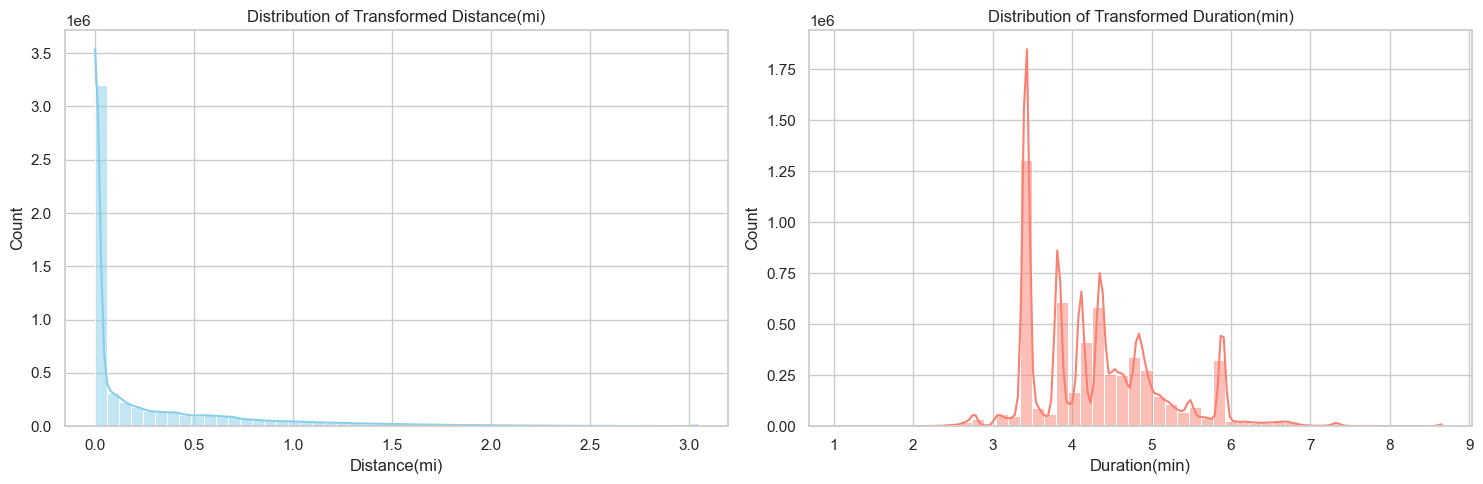

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
# กราฟการกระจายตัวของระยะทาง
sns.histplot(df_train_clean['Distance(mi)'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Transformed Distance(mi)')
axes[0].set_xlabel('Distance(mi)')
# กราฟการกระจายตัวของระยะเวลา
sns.histplot(df_train_clean['Duration(min)'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Transformed Duration(min)')
axes[1].set_xlabel('Duration(min)')

plt.tight_layout()
plt.show()

ยิ่งอุบัติเหตุกินระยะทาง (Distance) ยาวขึ้น ก็มีแนวโน้มที่จะใช้เวลาเคลียร์ (Duration) นานขึ้นตามไปด้วย" ดังนั้นการออกแบบโมเดลแบบ Chained Regression ที่เอาระยะทางไปเป็น Input ให้โมเดลระยะเวลา จะช่วยเพิ่มความแม่นยำได้แน่นอน

## Chained Regression
ยืนยันว่าการใช้ chained Regression เป็นเเนวคิดที่ถูกต้องโดยจะดูความสัมพันธ์ว่าถ้าระยะทางอุบัติเหตุ (Distance) มากขึ้น จะส่งผลให้ระยะเวลาเคลียร์ (Duration) นานขึ้นตามไปด้วยหรือไม่

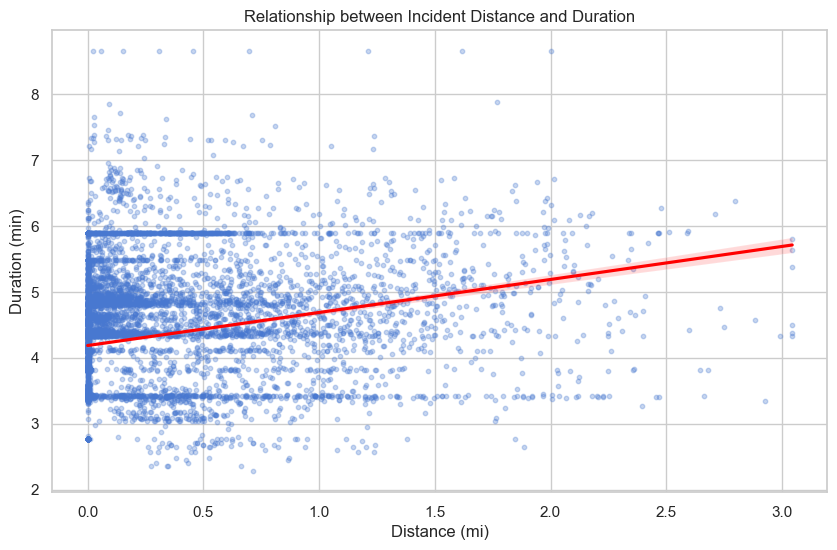

In [6]:
plt.figure(figsize=(10,6))

df_sample = df_train_clean.sample(n=10000, random_state=42)

sns.regplot(data=df_sample, x='Distance(mi)', y='Duration(min)',
            scatter_kws={'alpha':0.3,'s':10}, line_kws={'color':'red'})
plt.title('Relationship between Incident Distance and Duration')
plt.xlabel('Distance (mi)')
plt.ylabel('Duration (min)')
plt.show()

#### ปัจจัยเเวดล้อมมีผลต่อเป้าหมายอย่างไร? (Featur vs Target)
Weather_Group มีผลต่อ Duration หรือไม่?


C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\2441909486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean, x='Weather_Group', y='Duration(min)', order=order_duration,palette='Set2')


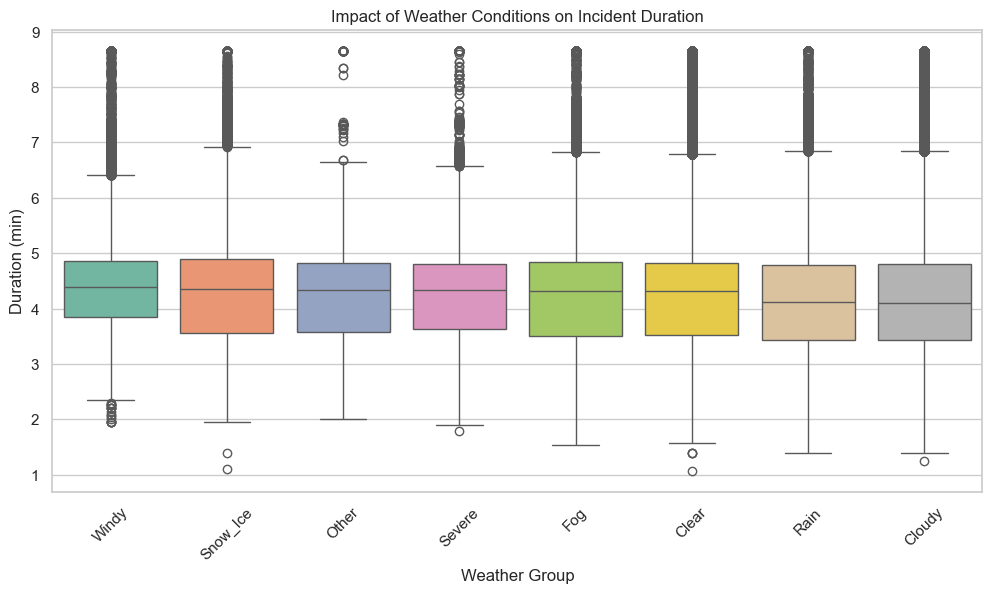

In [7]:
plt.figure(figsize=(12,6))

order_duration = df_train_clean.groupby('Weather_Group')['Duration(min)'].median().sort_values(ascending=False).index

sns.boxplot(data=df_train_clean, x='Weather_Group', y='Duration(min)', order=order_duration,palette='Set2')

plt.title('Impact of Weather Conditions on Incident Duration')
plt.xlabel('Weather Group')
plt.ylabel('Duration (min)')
plt.xticks(rotation=45)
plt.show()

กราฟ Boxplot แสดงให้เห็นว่ากลุ่มสภาพอากาศแบบ Windy, Snow_Ice และ Severe มีค่ามัธยฐาน (เส้นกลางกล่อง) และการกระจายตัวขยับสูงกว่ากลุ่ม Clear, Rain หรือ Cloudy อย่างเห็นได้ชัด

#### ตรวจสอบความซํ้าซ้อนของตัวเเปรต้น (Multicollinearity)
เช็คก่อนว่าตัวแปรต้น (Features) ไม่ได้มีความสัมพันธ์กันเองสูงเกินไปจนโมเดลสับสน

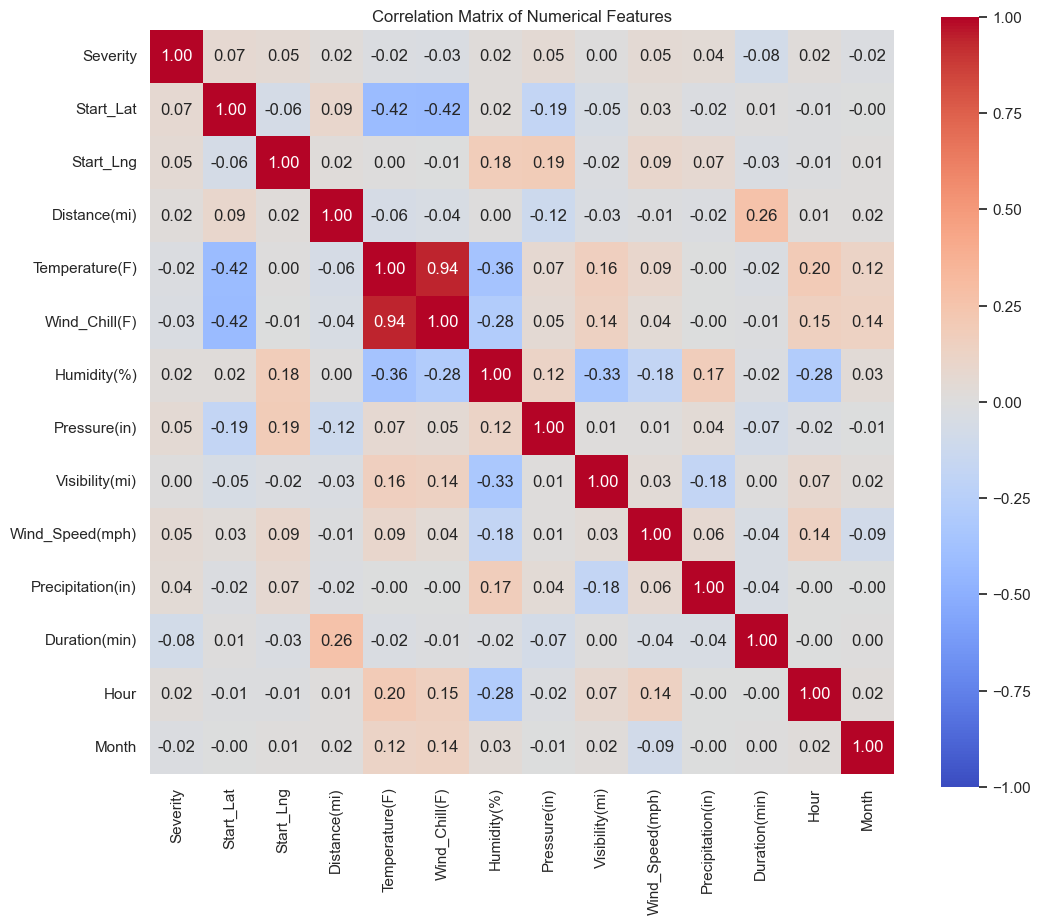

In [8]:
num_cols = df_train_clean.select_dtypes(include=['float64','int64']).columns
df_num = df_train_clean[num_cols]

corr_matrix = df_num.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1,vmax=1,square=True)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Temporal Analysis
ดูว่าชั่วโมงเร่งด่วน หรือเดือนที่มีฤดูหนาว ทำให้ระยะเวลาเคลียร์อุบัติเหตุนานขึ้นหรือไม่

C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\256266445.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_duration, x='Month', y='Duration(min)', ax=axes[1], palette='viridis')


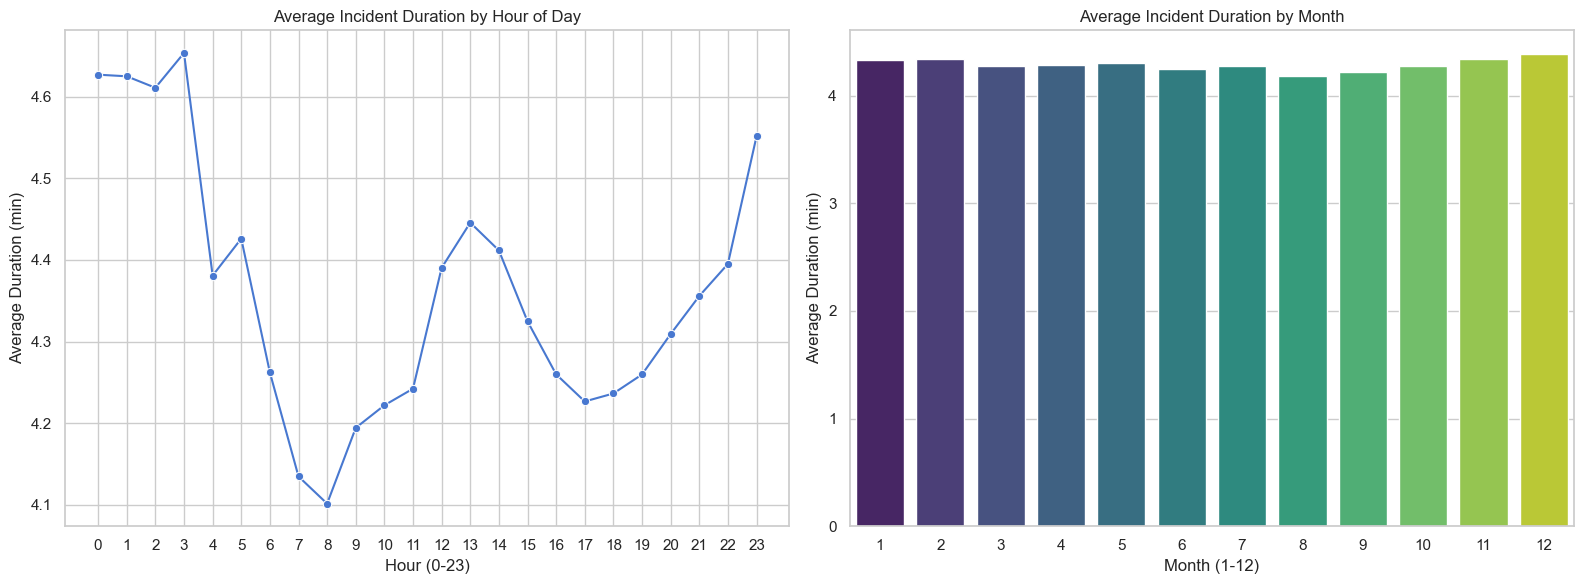

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1.1 ดูค่าเฉลี่ยของ Duration ในแต่ละชั่วโมงของวัน
hourly_duration = df_train_clean.groupby('Hour')['Duration(min)'].mean().reset_index()
sns.lineplot(data=hourly_duration, x='Hour', y='Duration(min)', marker='o', ax=axes[0], color='b')
axes[0].set_title('Average Incident Duration by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Average Duration (min)')
axes[0].set_xticks(range(0, 24))

# 1.2 ดูค่าเฉลี่ยของ Duration ในแต่ละเดือน
monthly_duration = df_train_clean.groupby('Month')['Duration(min)'].mean().reset_index()
sns.barplot(data=monthly_duration, x='Month', y='Duration(min)', ax=axes[1], palette='viridis')
axes[1].set_title('Average Incident Duration by Month')
axes[1].set_xlabel('Month (1-12)')
axes[1].set_ylabel('Average Duration (min)')

plt.tight_layout()
plt.show()


* ช่วงเวลาในแต่ละวัน (Hour):อุบัติเหตุช่วงกลางคืนถึงเช้ามืด (เที่ยงคืน - ตี 3) ใช้เวลาเคลียร์นานที่สุด ในขณะที่ช่วงเวลาเร่งด่วนตอนเช้า (7.00 - 8.00 น.) กลับใช้เวลาเคลียร์ต่ำที่สุด ซึ่งตีความได้ว่าอุบัติเหตุในชั่วโมงเร่งด่วนมักเป็นการชนท้ายเบาๆ ในเขตเมือง และเจ้าหน้าที่มีความพร้อมสูง ส่วนตอนกลางคืนมักรุนแรงกว่าและเจ้าหน้าที่เข้าถึงได้ช้ากว่า
* ช่วงเดือน (Month):เดือนในฤดูหนาว (ธันวาคม, มกราคม, กุมภาพันธ์) มีค่าเฉลี่ยของระยะเวลาเคลียร์ถนนสูงกว่าเดือนอื่นๆ เล็กน้อย ซึ่งน่าจะเป็นผลกระทบจากสภาพอากาศที่มีหิมะหรือน้ำแข็งกวนการทำงาน

### Spatial Analysis
ค้นหารัฐที่จัดการอุบัติเหตุได้ช้าที่สุด และพล็อตแผนที่จุดเกิดเหตุ

C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\3777197663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, ax=axes[0], palette='magma')


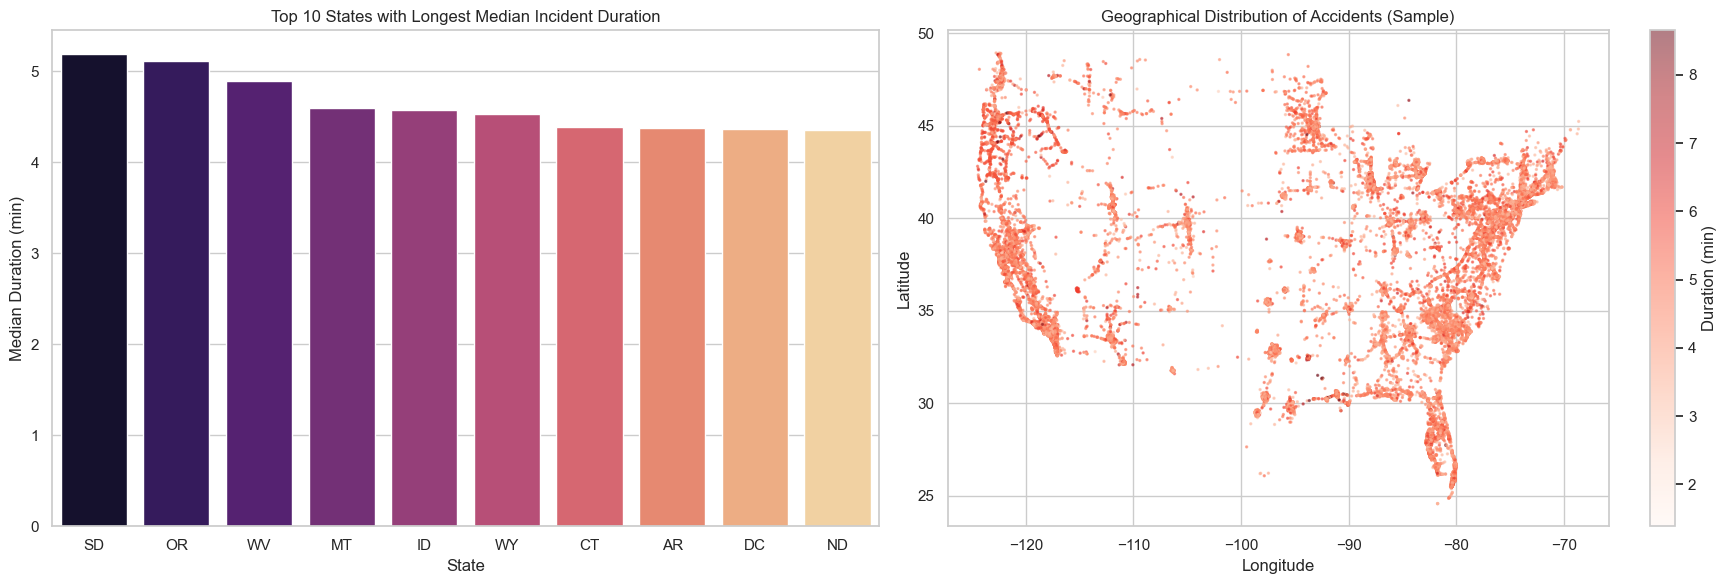

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 2.1 จัดอันดับ 10 รัฐที่ใช้เวลาเคลียร์นานที่สุด (ใช้ Median เพื่อกัน Outlier กวน)
top_states = df_train_clean.groupby('State')['Duration(min)'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_states.index, y=top_states.values, ax=axes[0], palette='magma')
axes[0].set_title('Top 10 States with Longest Median Incident Duration')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Median Duration (min)')

# 2.2 พล็อตแผนที่อเมริกาแบบคร่าวๆ จากจุดเกิดเหตุ (สุ่มมา 50,000 จุด)
df_sample = df_train_clean.sample(n=50000, random_state=42)
# ใช้ scatter สีตามระยะเวลา ยิ่งสีเข้มยิ่งนาน
sc = axes[1].scatter(df_sample['Start_Lng'], df_sample['Start_Lat'], 
                     c=df_sample['Duration(min)'], cmap='Reds', alpha=0.5, s=2)
axes[1].set_title('Geographical Distribution of Accidents (Sample)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(sc, ax=axes[1], label='Duration (min)')

plt.tight_layout()
plt.show()

* รัฐที่ล่าช้าที่สุด (Top 10 States): รัฐที่ใช้เวลาเคลียร์ถนนนานที่สุด (พิจารณาจากค่ามัธยฐาน) ได้แก่ SD (South Dakota), OR (Oregon), WV (West Virginia) และ MT (Montana) รัฐเหล่านี้มักมีพื้นที่ชนบท กว้างใหญ่ ห่างไกล หรือเป็นภูเขา ทำให้ทีมกู้ภัยใช้เวลาเดินทางนานขึ้น
* การกระจายตัว (Map): จุดเกิดเหตุกระจุกตัวหนาแน่นตามแนวชายฝั่งตะวันออกและตะวันตกซึ่งเป็นพื้นที่ที่มีประชากรหนาแน่น แต่จุดที่ใช้เวลาเคลียร์นานๆ (สีเข้ม) มักจะกระจายตัวออกไปในพื้นที่รอบนอก

### Road Infrastructure
สี่แยก ทางรถไฟ หรือป้ายหยุด มีผลทำให้ระยะเวลาการติดขัดเพิ่มขึ้นจริงหรือ

C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\2339976241.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean, x=col, y='Duration(min)', ax=axes[i], palette='Set1')
C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\2339976241.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean, x=col, y='Duration(min)', ax=axes[i], palette='Set1')
C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\2339976241.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean, x=col, y='Duration(min)',

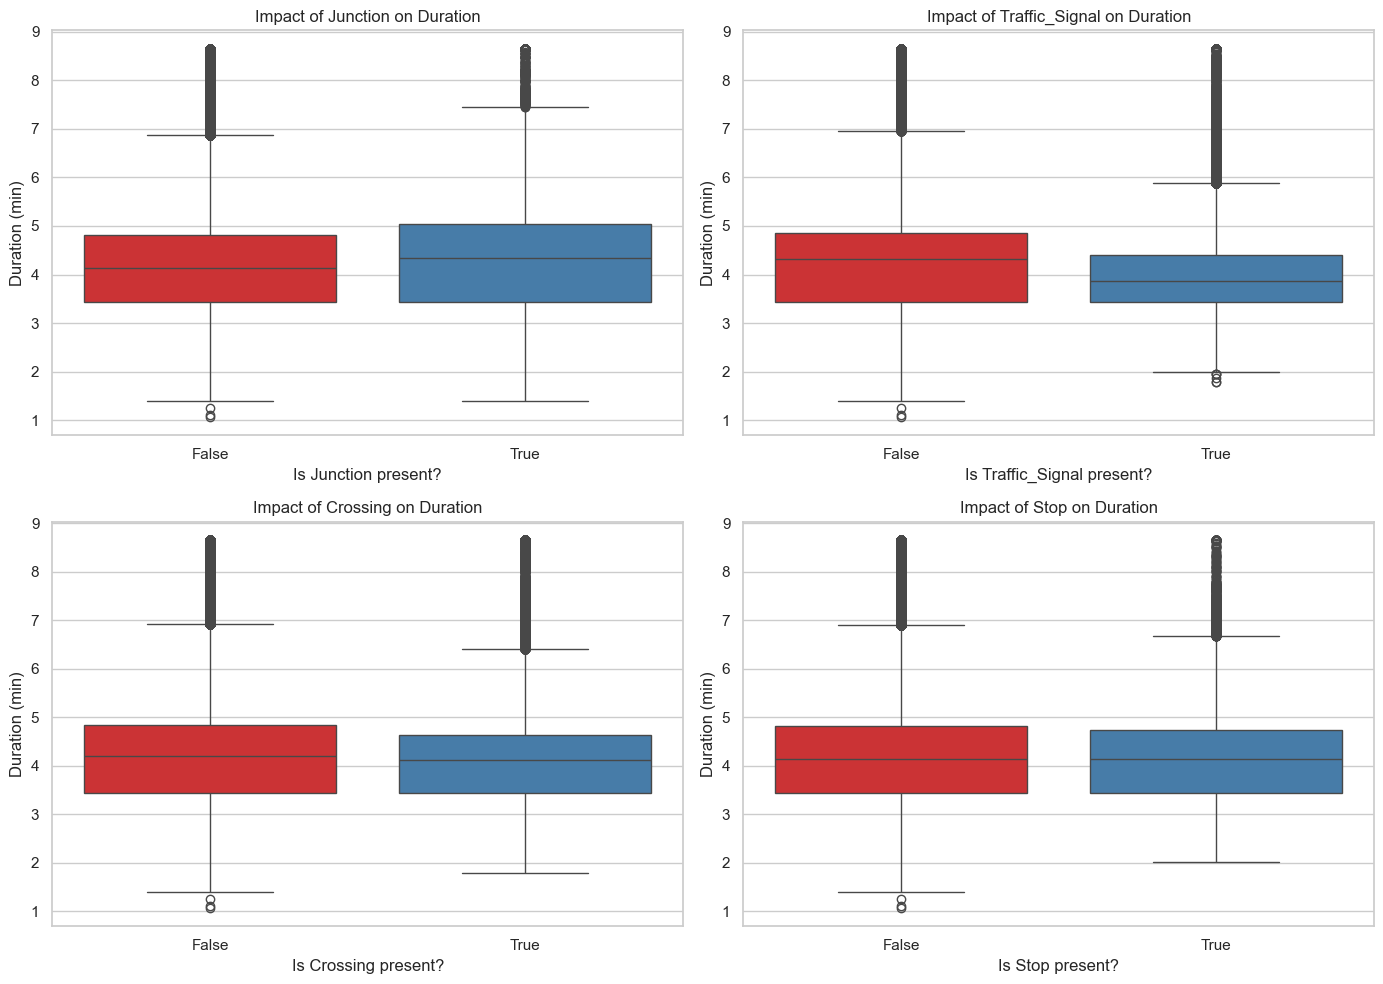

In [12]:
# เลือกตัวแปรสถานที่ที่เราสนใจ
poi_features = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(poi_features):
    # พล็อต Boxplot เพื่อเทียบว่าการมี (True) หรือไม่มี (False) สิ่งเหล่านี้ส่งผลต่อ Duration แค่ไหน
    sns.boxplot(data=df_train_clean, x=col, y='Duration(min)', ax=axes[i], palette='Set1')
    axes[i].set_title(f'Impact of {col} on Duration')
    axes[i].set_xlabel(f'Is {col} present?')
    axes[i].set_ylabel('Duration (min)')

plt.tight_layout()
plt.show()

* อุบัติเหตุในจุดที่ ไม่มี (False) สัญญาณไฟจราจร, ทางข้าม หรือป้ายหยุด กลับใช้เวลาเคลียร์นานกว่าจุดที่มี (True) ซึ่งแปลว่า อุบัติเหตุตามแยกในเมืองเคลียร์ได้เร็วกว่าอุบัติเหตุบนถนนหลวงทางตรงยาวๆ
* ในทางกลับกัน การเกิดอุบัติเหตุบริเวณ Junction (True) กลับทำให้ต้องใช้เวลาเคลียร์นานขึ้น เพราะจุดตัดไฮเวย์มักมีความซับซ้อนและใช้ความเร็วสูง

### Severity Impact
ตรวจสอบความสอดคล้องระหว่าง Severity ที่รายงาน กับความเป็นจริงของ Distance และ Duration

C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\1945893454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train_clean, x='Severity', y='Duration(min)', ax=axes[0], palette='pastel')
C:\Users\Kittithat\AppData\Local\Temp\ipykernel_24420\1945893454.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_clean, x='Severity', y='Distance(mi)', ax=axes[1], palette='pastel')


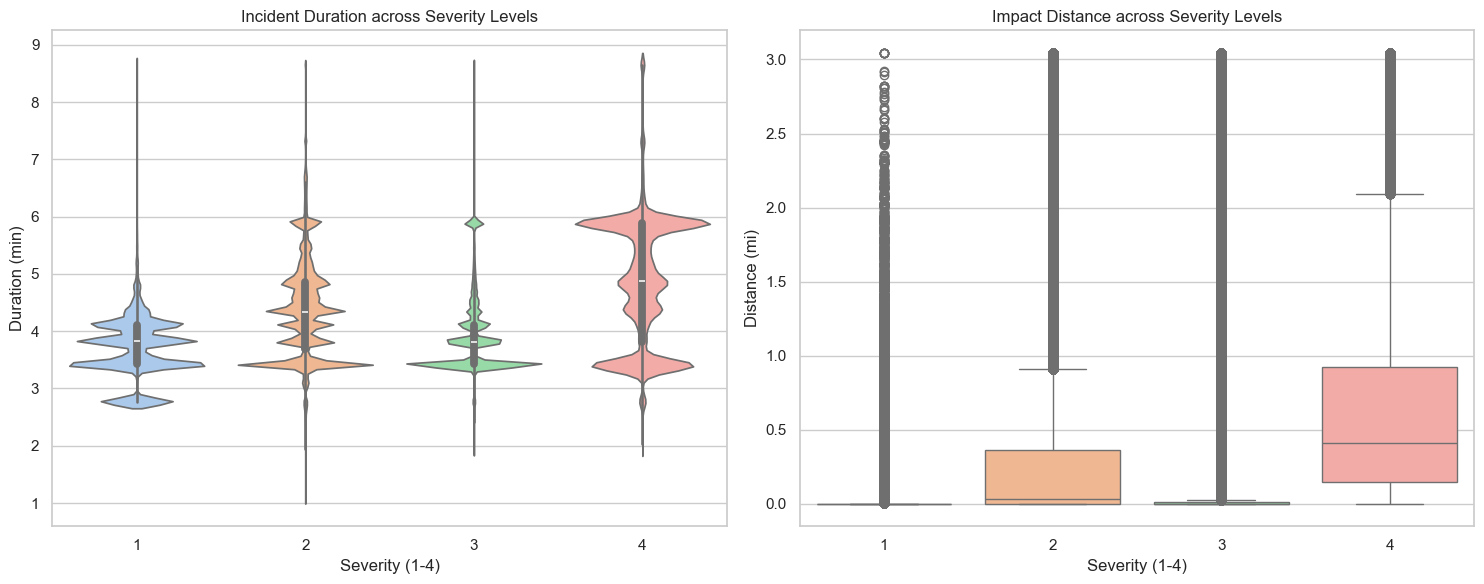

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 4.1 ความรุนแรง vs ระยะเวลา
sns.violinplot(data=df_train_clean, x='Severity', y='Duration(min)', ax=axes[0], palette='pastel')
axes[0].set_title('Incident Duration across Severity Levels')
axes[0].set_xlabel('Severity (1-4)')
axes[0].set_ylabel('Duration (min)')

# 4.2 ความรุนแรง vs ระยะทางที่ได้รับผลกระทบ
sns.boxplot(data=df_train_clean, x='Severity', y='Distance(mi)', ax=axes[1], palette='pastel')
axes[1].set_title('Impact Distance across Severity Levels')
axes[1].set_xlabel('Severity (1-4)')
axes[1].set_ylabel('Distance (mi)')

plt.tight_layout()
plt.show()

* กราฟยืนยันว่า Severity ระดับ 4 คือ "ของจริง" ครับ ทั้งในแง่ของระยะเวลา (Duration) ที่กราฟขยับขึ้นไปอยู่สูงกว่าระดับ 1-3 อย่างเห็นได้ชัด และโดยเฉพาะ ระยะทาง (Distance) ที่ระดับ 4 มีกล่อง (Boxplot) ที่กินพื้นที่กว้างและยาวกว่าระดับอื่นมหาศาล ข้อมูลนี้ช่วยยืนยันว่าฟีเจอร์ความรุนแรงเชื่อถือได้และมีประโยชน์ต่อโมเดลมาก

### Advanced Weather
หาจุดตัด (Threshold) ที่วิกฤต

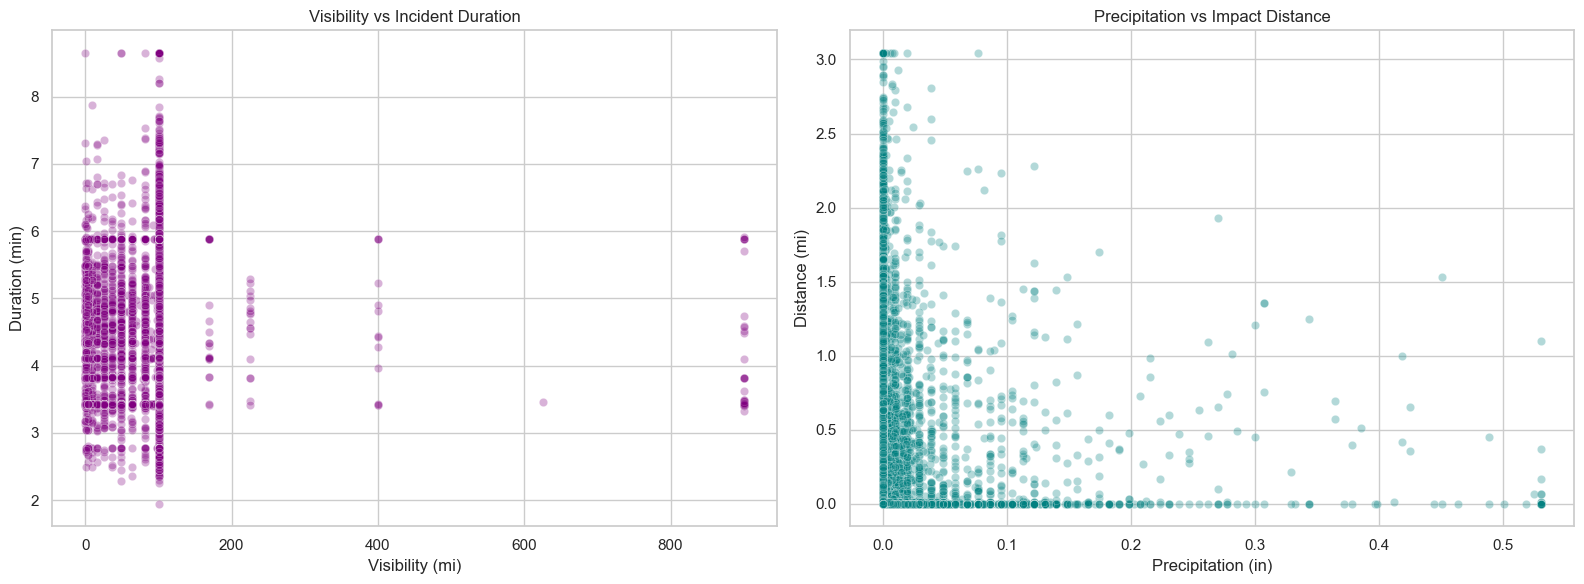

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_weather_sample = df_train_clean.sample(n=20000, random_state=42)

#ทัศนวิสัย (Visibility) vs ระยะเวลา
sns.scatterplot(data=df_weather_sample, x='Visibility(mi)', y='Duration(min)', 
                alpha=0.3, ax=axes[0], color='purple')
axes[0].set_title('Visibility vs Incident Duration')
axes[0].set_xlabel('Visibility (mi)')
axes[0].set_ylabel('Duration (min)')

#ปริมาณน้ำฝน/หิมะ (Precipitation) vs ระยะทางที่ได้รับผลกระทบ
sns.scatterplot(data=df_weather_sample, x='Precipitation(in)', y='Distance(mi)', 
                alpha=0.3, ax=axes[1], color='teal')
axes[1].set_title('Precipitation vs Impact Distance')
axes[1].set_xlabel('Precipitation (in)')
axes[1].set_ylabel('Distance (mi)')

plt.tight_layout()
plt.show()

* ทัศนวิสัย (Visibility): อุบัติเหตุส่วนใหญ่กระจุกตัวอยู่ที่ระยะการมองเห็นปกติ (ประมาณ 10 ไมล์) แต่เมื่อทัศนวิสัยตกต่ำลงเข้าใกล้ 0 ไมล์ ก็ยังมีอุบัติเหตุเกิดขึ้นอย่างหนาแน่นและมีระยะเวลาเคลียร์ที่แกว่งตัวสูง
* ปริมาณน้ำฝน (Precipitation): อุบัติเหตุที่กินระยะทางยาวๆ (Impact Distance สูง) กลับไม่ได้เกิดขึ้นในช่วงที่มีปริมาณฝน/หิมะตกหนักที่สุด แต่มักเกิดในช่วงที่ตกปรอยๆ หรือตกในระดับต่ำมากกว่า (อาจเพราะคนมักประมาทและใช้ความเร็วสูงอยู่)